In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
"""
==============================================================================
NOTEBOOK 2: EXPLORATORY DATA ANALYSIS & VISUALIZATION
==============================================================================

Project: Industrial-Scale Uplift Modeling for Ad Spend Optimization
Dataset: Criteo Uplift Modeling v2.1
Goal:    Deep exploratory analysis of the 2M sampled dataset to understand
         feature distributions, treatment-control balance, outcome rates,
         and identify modeling considerations.

Author:  Anurag Jain (M.Sc. Economics, IGIDR)
==============================================================================
"""

# Standard imports
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical tests
from scipy import stats

# Display settings
%matplotlib inline
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("✅ Environment setup complete")
print(f"   NumPy: {np.__version__}")
print(f"   Pandas: {pd.__version__}")

✅ Environment setup complete
   NumPy: 2.4.6
   Pandas: 2.3.3


In [4]:
# ============================================================================
# LOAD DATA
# ============================================================================
# We'll re-create the stratified sample (faster than uploading)

DATA_PATH = '/kaggle/input/datasets/evgeniypolin/criteo-uplift-v2-1/criteo-uplift-v2.1.csv'

print("📥 Loading data in chunks and creating stratified sample...")

chunk_size = 1_000_000
sample_fraction = 0.15
sampled_chunks = []

chunks = pd.read_csv(DATA_PATH, chunksize=chunk_size)

for i, chunk in enumerate(chunks):
    sampled = (
        chunk.groupby(['treatment', 'conversion'], group_keys=False)
        .apply(lambda x: x.sample(frac=sample_fraction, random_state=42))
    )
    sampled_chunks.append(sampled)
    print(f"  Chunk {i+1}: {len(sampled):,} rows sampled")

df = pd.concat(sampled_chunks, ignore_index=True)

# Memory optimization
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='integer')

print(f"\n✅ Final dataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

📥 Loading data in chunks and creating stratified sample...
  Chunk 1: 150,000 rows sampled
  Chunk 2: 150,000 rows sampled
  Chunk 3: 150,000 rows sampled
  Chunk 4: 150,000 rows sampled
  Chunk 5: 150,000 rows sampled
  Chunk 6: 150,000 rows sampled
  Chunk 7: 149,999 rows sampled
  Chunk 8: 150,000 rows sampled
  Chunk 9: 150,000 rows sampled
  Chunk 10: 150,000 rows sampled
  Chunk 11: 150,000 rows sampled
  Chunk 12: 150,000 rows sampled
  Chunk 13: 150,000 rows sampled
  Chunk 14: 146,939 rows sampled

✅ Final dataset: 2,096,938 rows × 16 columns
   Memory usage: 0.11 GB


In [5]:
# ============================================================================
# SECTION 1: BASIC DATASET OVERVIEW
# ============================================================================

print("="*70)
print("DATASET STRUCTURE")
print("="*70)
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
print(f"\nMissing values per column:")
print(df.isnull().sum())

DATASET STRUCTURE

Shape: (2096938, 16)

Columns: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'treatment', 'conversion', 'visit', 'exposure']

Data types:
f0            float32
f1            float32
f2            float32
f3            float32
f4            float32
f5            float32
f6            float32
f7            float32
f8            float32
f9            float32
f10           float32
f11           float32
treatment        int8
conversion       int8
visit            int8
exposure         int8
dtype: object

Memory usage: 109.04 MB

Missing values per column:
f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
visit         0
exposure      0
dtype: int64


In [6]:
# ============================================================================
# SECTION 2: SUMMARY STATISTICS
# ============================================================================

print("="*70)
print("FEATURE SUMMARY STATISTICS")
print("="*70)

# Separate features from treatment/outcome columns
feature_cols = [f'f{i}' for i in range(12)]
meta_cols = ['treatment', 'conversion', 'visit', 'exposure']

print("\n📊 Feature columns (f0-f11):")
df[feature_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

FEATURE SUMMARY STATISTICS

📊 Feature columns (f0-f11):


,mean,std,min,25%,50%,75%,max
f0,19.6261,5.3948,12.6164,12.6164,21.9272,24.4575,26.7453
f1,10.0699,0.1177,10.0597,10.0597,10.0597,10.0597,15.0696
f2,8.4464,0.3085,8.2144,8.2144,8.2144,8.7227,9.0520
f3,4.1797,1.3268,-7.7006,4.6799,4.6799,4.6799,4.6799
f4,10.3387,0.3605,10.2805,10.2805,10.2805,10.2805,21.1235
f5,4.0285,0.4414,-8.1338,4.1155,4.1155,4.1155,4.1155
f6,-4.1550,4.5768,-31.4298,-6.6993,-2.4111,0.2944,0.2944
f7,5.1019,1.1947,4.8338,4.8338,4.8338,4.8338,11.9984
f8,3.9336,0.0745,3.6351,3.9108,3.9719,3.9719,3.9719
f9,16.0252,7.0045,13.1901,13.1901,13.1901,13.1901,75.2950


In [7]:
# ============================================================================
# SECTION 3: TREATMENT & OUTCOME DISTRIBUTIONS
# ============================================================================

print("📊 TREATMENT GROUP DISTRIBUTION")
print("="*50)
treatment_counts = df['treatment'].value_counts()
treatment_pct = df['treatment'].value_counts(normalize=True) * 100

for val in [0, 1]:
    label = "Control (no ad)" if val == 0 else "Treatment (saw ad)"
    print(f"  {label}: {treatment_counts[val]:,} ({treatment_pct[val]:.2f}%)")

print(f"\n⚠️  Imbalance ratio: {treatment_counts[1] / treatment_counts[0]:.2f}:1")

print("\n\n📊 VISIT DISTRIBUTION")
print("="*50)
visit_rate = df['visit'].mean() * 100
print(f"  Overall visit rate: {visit_rate:.3f}%")
print(f"  Visit rate (Control): {df[df['treatment']==0]['visit'].mean()*100:.3f}%")
print(f"  Visit rate (Treatment): {df[df['treatment']==1]['visit'].mean()*100:.3f}%")

print("\n\n📊 CONVERSION DISTRIBUTION")
print("="*50)
conversion_rate = df['conversion'].mean() * 100
print(f"  Overall conversion rate: {conversion_rate:.3f}%")
print(f"  Conversion rate (Control): {df[df['treatment']==0]['conversion'].mean()*100:.3f}%")
print(f"  Conversion rate (Treatment): {df[df['treatment']==1]['conversion'].mean()*100:.3f}%")

# Naive ATE calculation
ate_naive_conversion = (
    df[df['treatment']==1]['conversion'].mean() - 
    df[df['treatment']==0]['conversion'].mean()
)
ate_naive_visit = (
    df[df['treatment']==1]['visit'].mean() - 
    df[df['treatment']==0]['visit'].mean()
)

print(f"\n💡 NAIVE AVERAGE TREATMENT EFFECT (ATE)")
print(f"   On Visit: {ate_naive_visit*100:+.3f} pp")
print(f"   On Conversion: {ate_naive_conversion*100:+.3f} pp")
print(f"\n   ⚠️  These are NAIVE estimates — real causal analysis comes next!")

📊 TREATMENT GROUP DISTRIBUTION
  Control (no ad): 314,539 (15.00%)
  Treatment (saw ad): 1,782,399 (85.00%)

⚠️  Imbalance ratio: 5.67:1


📊 VISIT DISTRIBUTION
  Overall visit rate: 4.694%
  Visit rate (Control): 3.827%
  Visit rate (Treatment): 4.847%


📊 CONVERSION DISTRIBUTION
  Overall conversion rate: 0.292%
  Conversion rate (Control): 0.194%
  Conversion rate (Treatment): 0.309%

💡 NAIVE AVERAGE TREATMENT EFFECT (ATE)
   On Visit: +1.020 pp
   On Conversion: +0.115 pp

   ⚠️  These are NAIVE estimates — real causal analysis comes next!


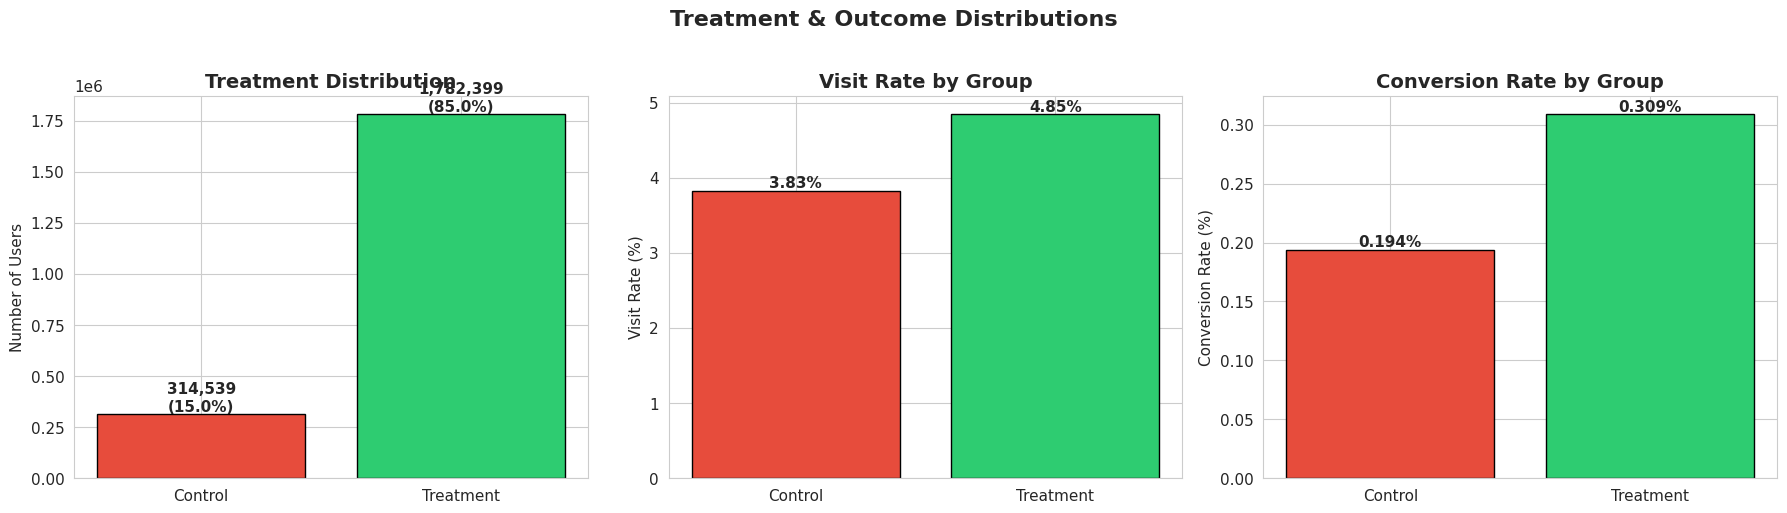

📊 KEY INSIGHTS:
   • Treatment imbalance: 85.0% treated vs 15.0% control
   • Naive visit lift: +1.020 percentage points
   • Naive conversion lift: +0.115 percentage points
   • Rare event: only 0.292% conversion rate overall


In [8]:
# ============================================================================
# VIZ 1: Treatment & Outcome Visualization
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Treatment distribution
treatment_data = df['treatment'].value_counts().sort_index()
axes[0].bar(['Control', 'Treatment'], treatment_data.values, 
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Treatment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(treatment_data.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)', 
                 ha='center', va='bottom', fontweight='bold')

# Visit rates by group
visit_by_treatment = df.groupby('treatment')['visit'].mean() * 100
axes[1].bar(['Control', 'Treatment'], visit_by_treatment.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Visit Rate by Group', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Visit Rate (%)')
for i, v in enumerate(visit_by_treatment.values):
    axes[1].text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

# Conversion rates by group
conv_by_treatment = df.groupby('treatment')['conversion'].mean() * 100
axes[2].bar(['Control', 'Treatment'], conv_by_treatment.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title('Conversion Rate by Group', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(conv_by_treatment.values):
    axes[2].text(i, v, f'{v:.3f}%', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Treatment & Outcome Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('treatment_outcome_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 KEY INSIGHTS:")
print(f"   • Treatment imbalance: {(df['treatment']==1).mean()*100:.1f}% treated vs {(df['treatment']==0).mean()*100:.1f}% control")
print(f"   • Naive visit lift: {ate_naive_visit*100:+.3f} percentage points")
print(f"   • Naive conversion lift: {ate_naive_conversion*100:+.3f} percentage points")
print(f"   • Rare event: only {conversion_rate:.3f}% conversion rate overall")

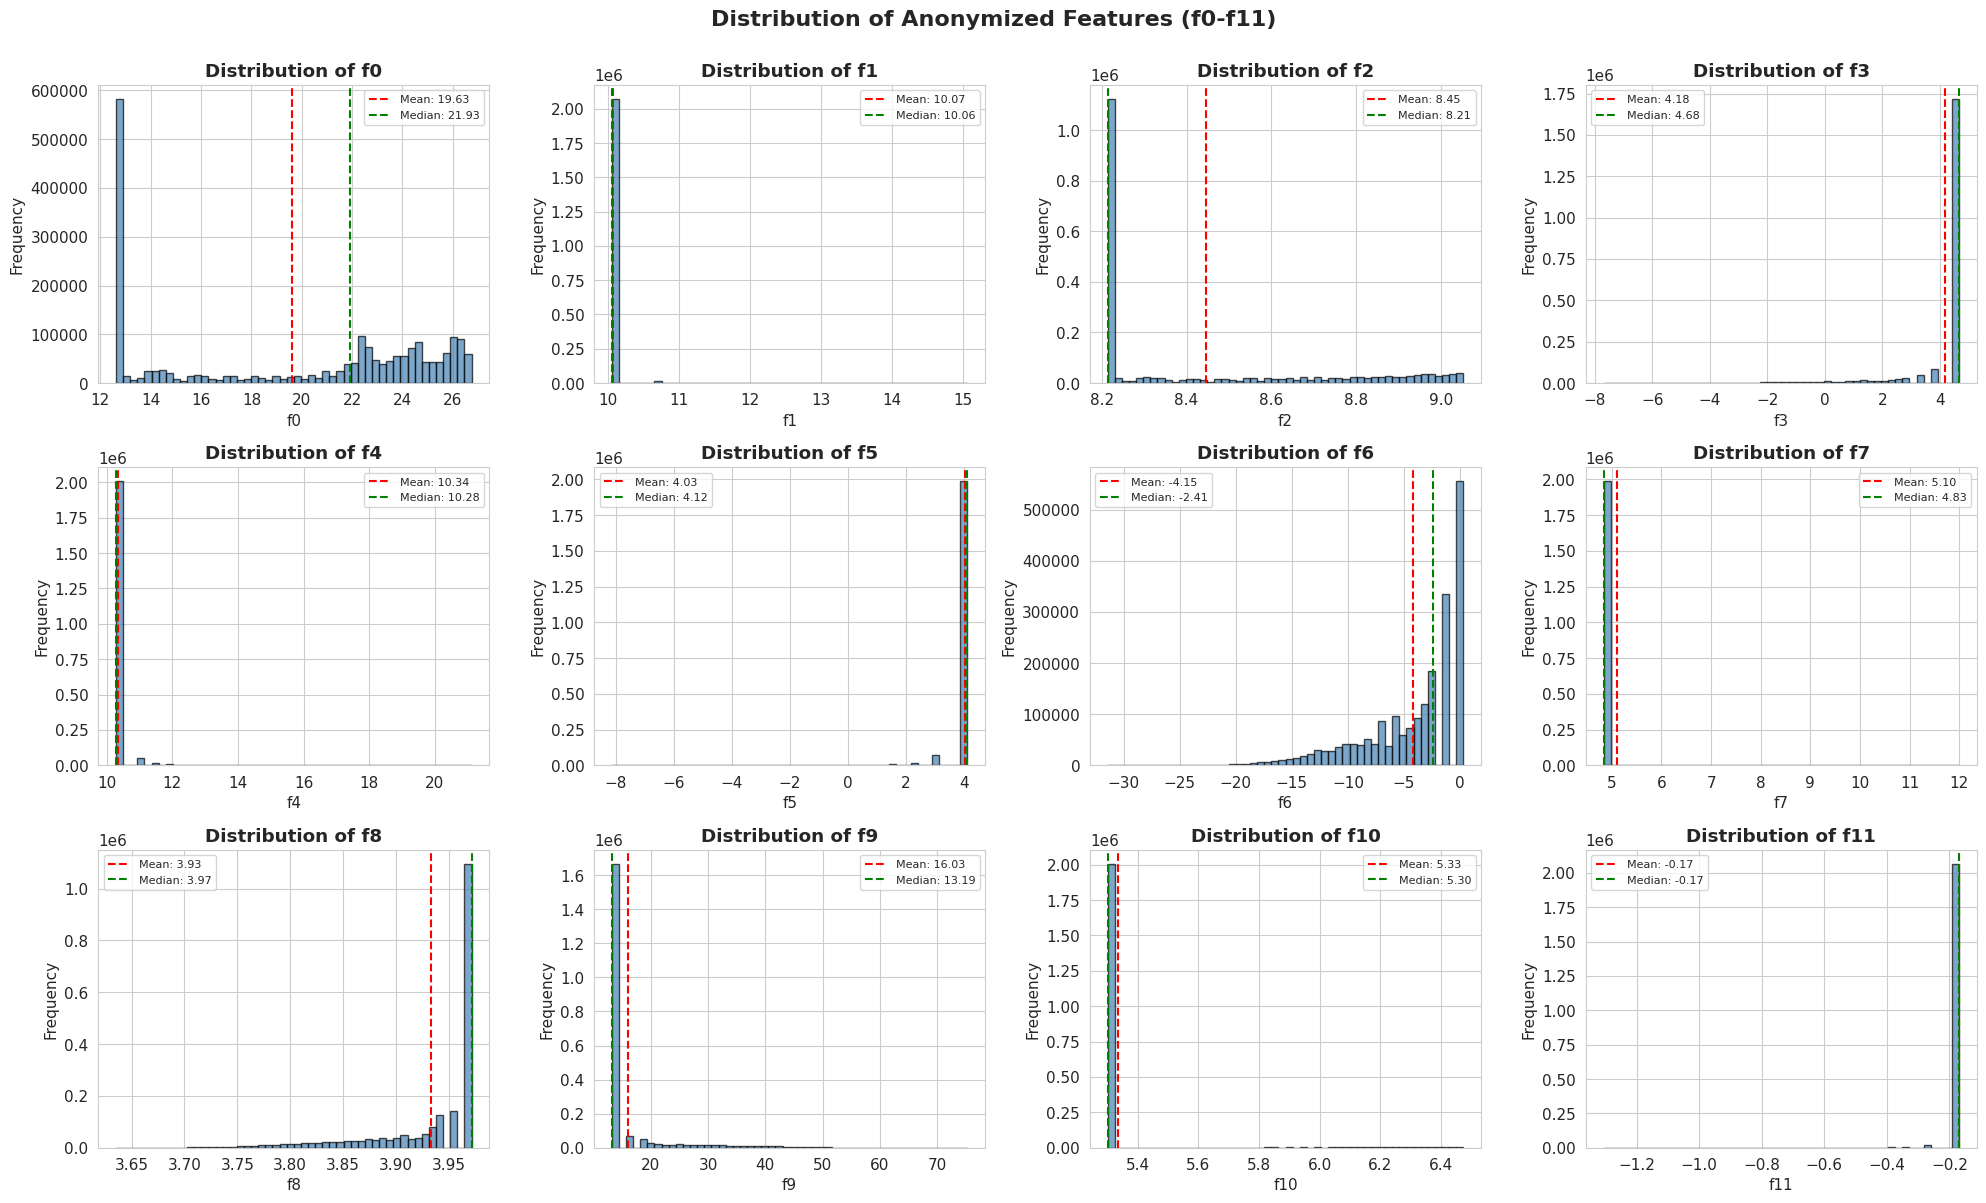

📊 INSIGHTS:
   • All features are anonymized (proprietary Criteo features)
   • Distributions vary significantly across features
   • Some appear skewed → may benefit from transformation in modeling


In [9]:
# ============================================================================
# SECTION 4: FEATURE DISTRIBUTIONS
# ============================================================================
# Since features are anonymized, we examine their statistical properties

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    
    # Add mean and median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Anonymized Features (f0-f11)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

print("📊 INSIGHTS:")
print("   • All features are anonymized (proprietary Criteo features)")
print("   • Distributions vary significantly across features")
print("   • Some appear skewed → may benefit from transformation in modeling")

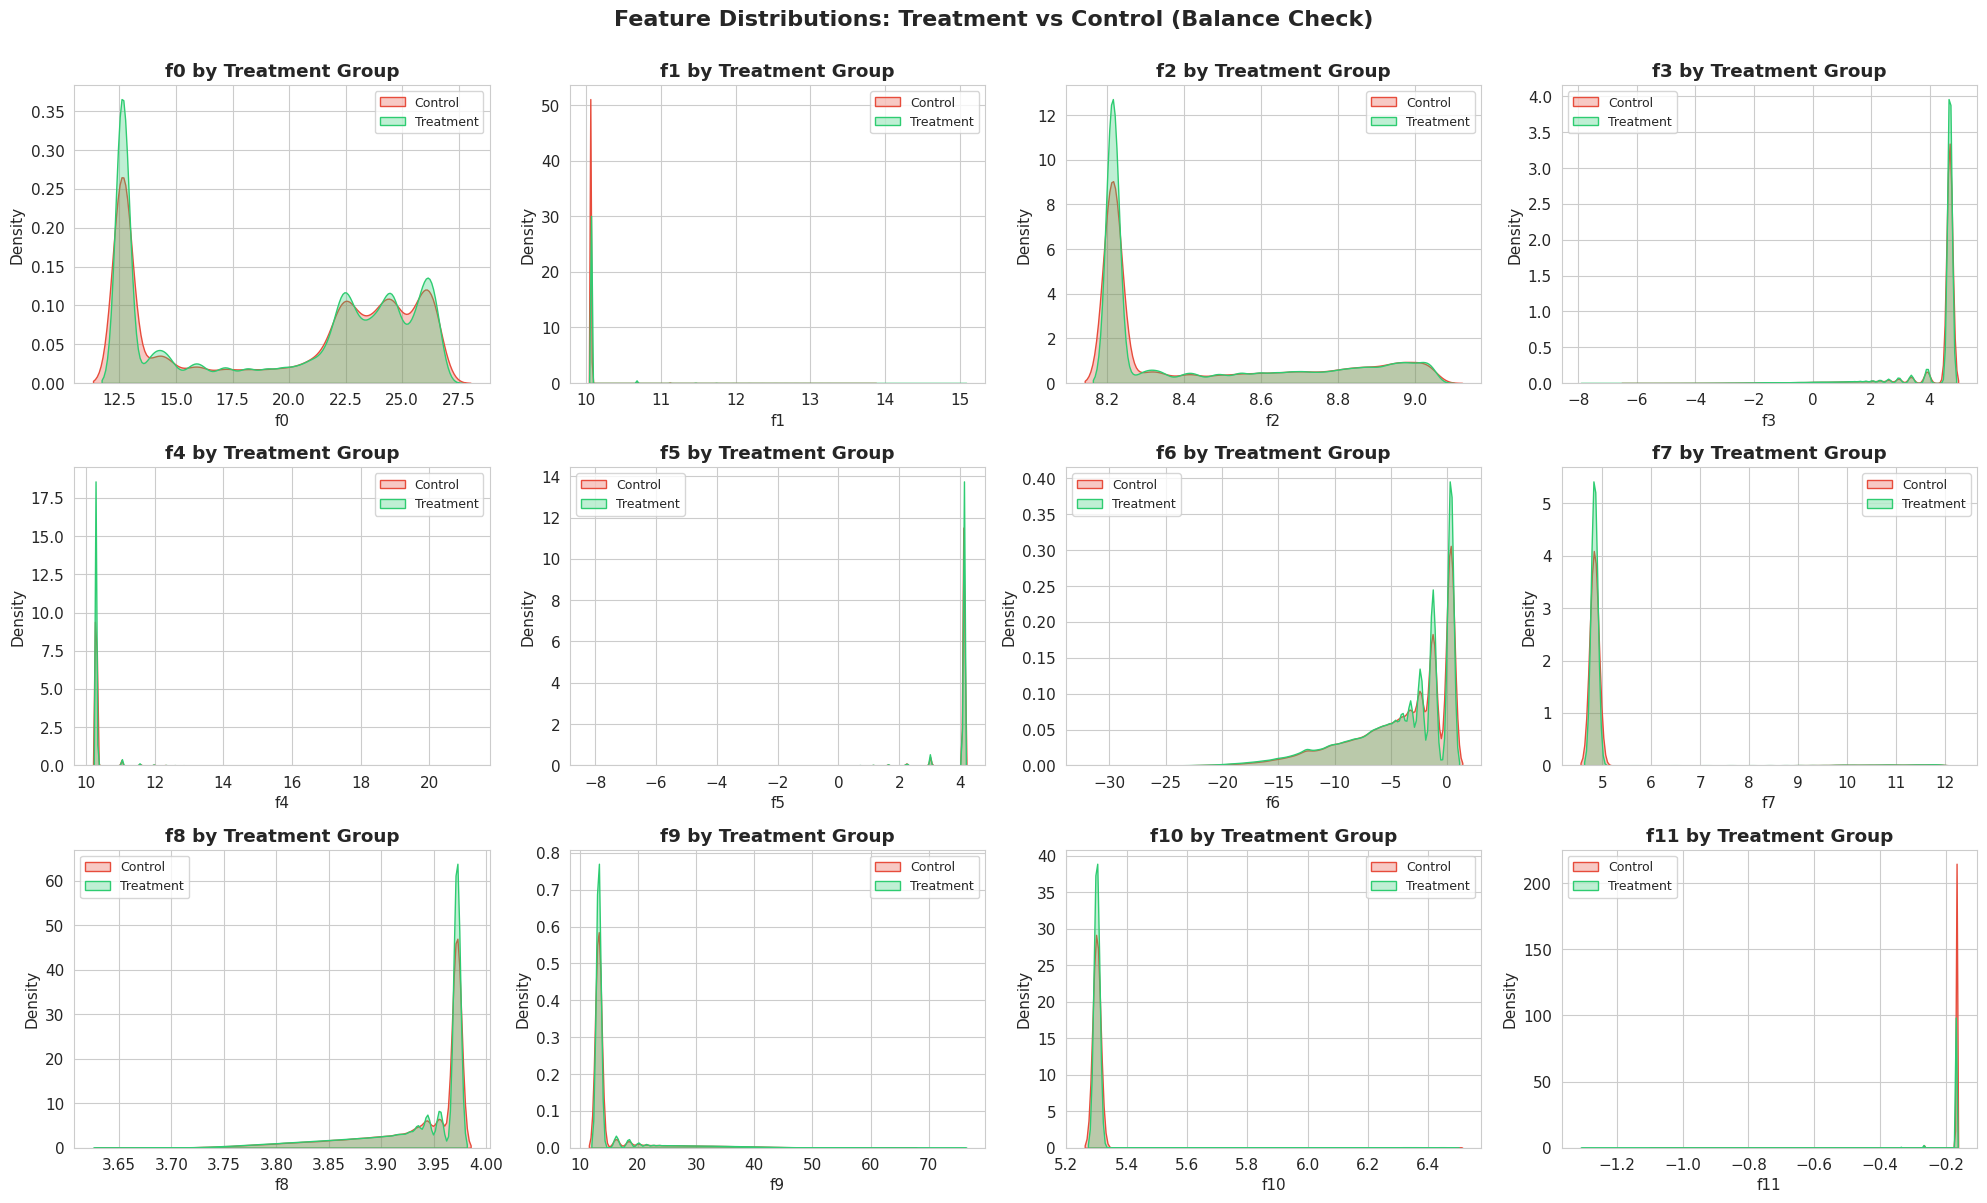

In [10]:
# ============================================================================
# SECTION 5: FEATURE DISTRIBUTIONS BY TREATMENT GROUP
# ============================================================================
# CRITICAL FOR CAUSAL INFERENCE: We need features to be balanced across groups

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.kdeplot(data=df[df['treatment']==0], x=col, label='Control', 
                ax=axes[i], color='#e74c3c', fill=True, alpha=0.3)
    sns.kdeplot(data=df[df['treatment']==1], x=col, label='Treatment', 
                ax=axes[i], color='#2ecc71', fill=True, alpha=0.3)
    axes[i].set_title(f'{col} by Treatment Group', fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: Treatment vs Control (Balance Check)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('feature_balance_check.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
# ============================================================================
# SECTION 6: KS TEST FOR DISTRIBUTION DIFFERENCES
# ============================================================================
# Kolmogorov-Smirnov test: Are features distributed differently across groups?

print("="*70)
print("KOLMOGOROV-SMIRNOV TEST: Treatment vs Control")
print("="*70)
print("\nH0: Feature distributions are the same in both groups")
print("H1: Feature distributions differ between groups")
print("(Low p-value → significant difference → potential confounder)\n")

ks_results = []
for col in feature_cols:
    control_data = df[df['treatment']==0][col]
    treatment_data = df[df['treatment']==1][col]
    
    ks_stat, p_value = stats.ks_2samp(control_data, treatment_data)
    
    ks_results.append({
        'Feature': col,
        'KS Statistic': ks_stat,
        'P-Value': p_value,
        'Significant (p<0.05)': '⚠️ YES' if p_value < 0.05 else '✅ NO'
    })

ks_df = pd.DataFrame(ks_results)
print(ks_df.to_string(index=False))

print(f"\n💡 INTERPRETATION:")
significant_features = ks_df[ks_df['P-Value'] < 0.05]['Feature'].tolist()
print(f"   • {len(significant_features)} out of 12 features show significant differences")
if len(significant_features) > 0:
    print(f"   • Features differing across groups: {', '.join(significant_features)}")
    print(f"   • These features are potential confounders → must be controlled in causal analysis")

KOLMOGOROV-SMIRNOV TEST: Treatment vs Control

H0: Feature distributions are the same in both groups
H1: Feature distributions differ between groups
(Low p-value → significant difference → potential confounder)

Feature  KS Statistic  P-Value Significant (p<0.05)
     f0        0.0080   0.0000               ⚠️ YES
     f1        0.0027   0.0421               ⚠️ YES
     f2        0.0038   0.0009               ⚠️ YES
     f3        0.0129   0.0000               ⚠️ YES
     f4        0.0027   0.0356               ⚠️ YES
     f5        0.0060   0.0000               ⚠️ YES
     f6        0.0124   0.0000               ⚠️ YES
     f7        0.0060   0.0000               ⚠️ YES
     f8        0.0087   0.0000               ⚠️ YES
     f9        0.0071   0.0000               ⚠️ YES
    f10        0.0028   0.0291               ⚠️ YES
    f11        0.0012   0.8359                 ✅ NO

💡 INTERPRETATION:
   • 11 out of 12 features show significant differences
   • Features differing across groups

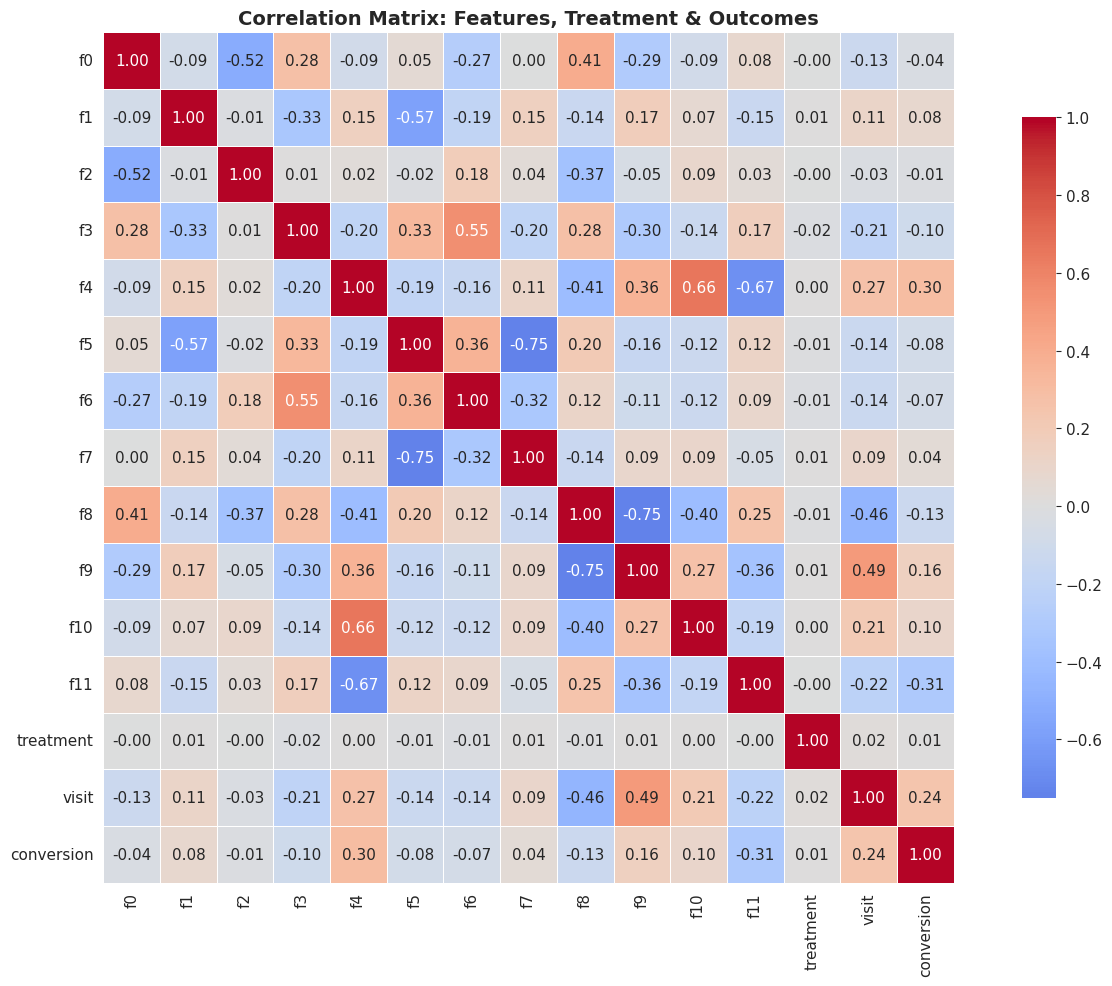


📊 TOP FEATURES CORRELATED WITH CONVERSION:
f11   0.3102
f4    0.2971
f9    0.1557
f8    0.1298
f3    0.1037
Name: conversion, dtype: float64

📊 TOP FEATURES CORRELATED WITH VISIT:
f9    0.4949
f8    0.4574
f4    0.2678
f11   0.2183
f3    0.2065
Name: visit, dtype: float64

📊 FEATURE CORRELATION WITH TREATMENT:
f3   0.0163
f6   0.0138
f5   0.0107
f1   0.0085
f9   0.0085
Name: treatment, dtype: float64


In [12]:
# ============================================================================
# SECTION 7: CORRELATION MATRIX
# ============================================================================

corr_matrix = df[feature_cols + ['treatment', 'visit', 'conversion']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix: Features, Treatment & Outcomes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

# Print top correlations with outcomes
print("\n📊 TOP FEATURES CORRELATED WITH CONVERSION:")
conv_corr = corr_matrix['conversion'].drop(['conversion', 'visit', 'treatment']).abs().sort_values(ascending=False)
print(conv_corr.head(5))

print("\n📊 TOP FEATURES CORRELATED WITH VISIT:")
visit_corr = corr_matrix['visit'].drop(['conversion', 'visit', 'treatment']).abs().sort_values(ascending=False)
print(visit_corr.head(5))

print("\n📊 FEATURE CORRELATION WITH TREATMENT:")
treat_corr = corr_matrix['treatment'].drop(['conversion', 'visit', 'treatment']).abs().sort_values(ascending=False)
print(treat_corr.head(5))

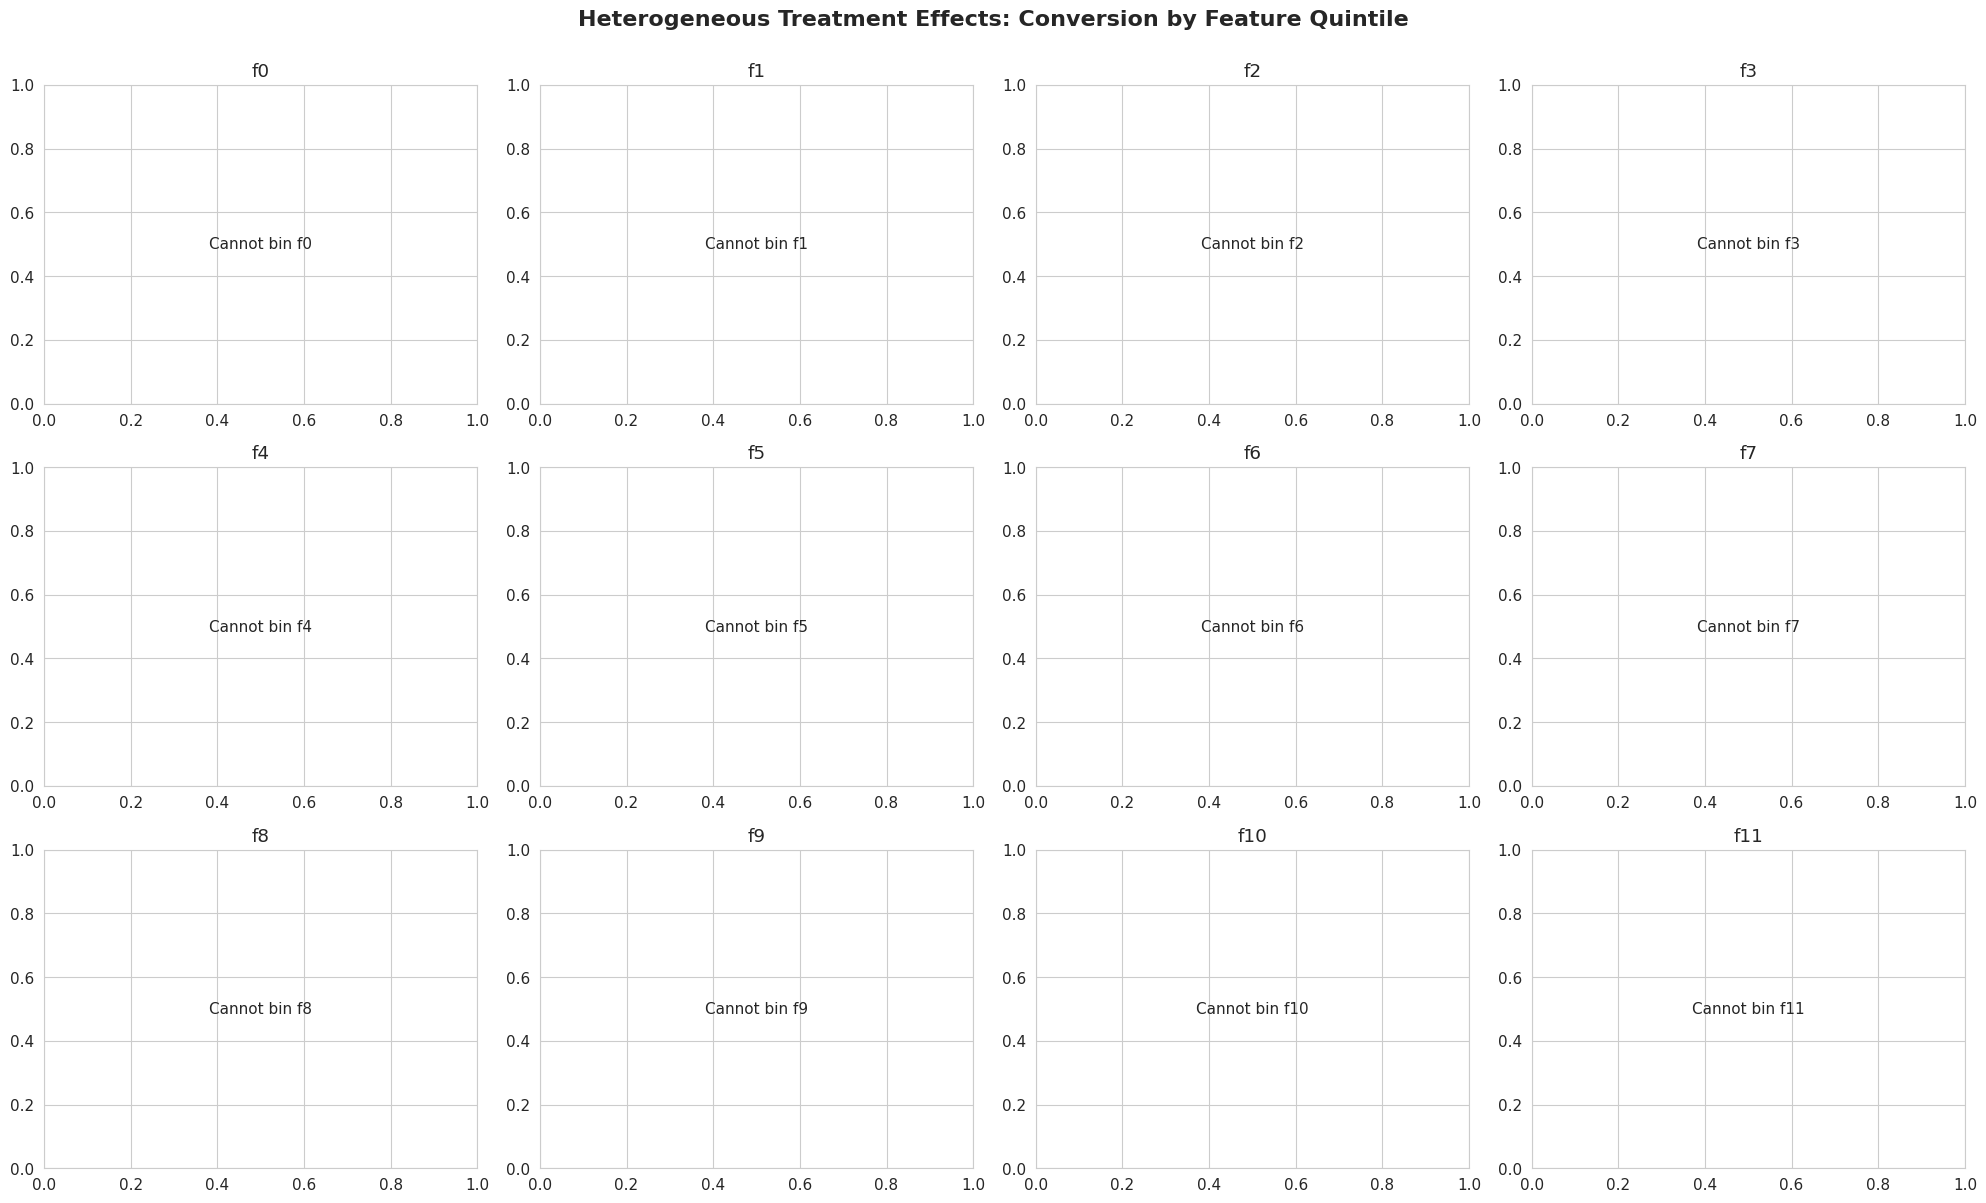

💡 INSIGHT: If the gap between green (treatment) and red (control) bars
   VARIES across quintiles → strong evidence of heterogeneous treatment effects
   → This is exactly what uplift modeling will capture!


In [14]:
# ============================================================================
# SECTION 8: CONVERSION RATE BY FEATURE QUINTILES (Heterogeneity Hints)
# ============================================================================
# Bin each feature into 5 groups, see if conversion varies → heterogeneity hint

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    try:
        df[f'{col}_bin'] = pd.qcut(df[col], q=5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'], duplicates='drop')
        
        conv_by_bin = df.groupby([f'{col}_bin', 'treatment'])['conversion'].mean().unstack() * 100
        
        conv_by_bin.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'], 
                         edgecolor='black', width=0.7)
        axes[i].set_title(f'Conversion Rate by {col} Quintiles', fontweight='bold')
        axes[i].set_xlabel(f'{col} Quintile')
        axes[i].set_ylabel('Conversion Rate (%)')
        axes[i].legend(['Control', 'Treatment'], fontsize=8)
        axes[i].tick_params(axis='x', rotation=0)
        
        df.drop(columns=[f'{col}_bin'], inplace=True)
    except Exception as e:
        axes[i].text(0.5, 0.5, f'Cannot bin {col}', ha='center', va='center')
        axes[i].set_title(f'{col}')

plt.suptitle('Heterogeneous Treatment Effects: Conversion by Feature Quintile', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('heterogeneity_check.png', dpi=100, bbox_inches='tight')
plt.show()

print("💡 INSIGHT: If the gap between green (treatment) and red (control) bars")
print("   VARIES across quintiles → strong evidence of heterogeneous treatment effects")
print("   → This is exactly what uplift modeling will capture!")

In [15]:
# ============================================================================
# SECTION 9: EXECUTIVE SUMMARY OF FINDINGS
# ============================================================================

print("="*70)
print("📋 EDA EXECUTIVE SUMMARY")
print("="*70)

print(f"""
🔢 DATASET CHARACTERISTICS
   • Total samples: {len(df):,} (stratified from 13.9M)
   • Features: 12 anonymized numerical (f0-f11)
   • Memory footprint: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB

⚖️ TREATMENT ASSIGNMENT
   • Treatment group: {(df['treatment']==1).sum():,} users ({(df['treatment']==1).mean()*100:.1f}%)
   • Control group: {(df['treatment']==0).sum():,} users ({(df['treatment']==0).mean()*100:.1f}%)
   • Imbalance ratio: {(df['treatment']==1).sum() / (df['treatment']==0).sum():.1f}:1
   ⚠️  Heavy imbalance → use X-Learner/R-Learner (robust to imbalance)

📈 OUTCOMES
   • Visit rate: {df['visit'].mean()*100:.3f}% overall
   • Conversion rate: {df['conversion'].mean()*100:.3f}% overall
   ⚠️  Conversion is a RARE EVENT → use AUC/Qini, not accuracy

💡 NAIVE TREATMENT EFFECTS (uncorrected)
   • Visit lift: {ate_naive_visit*100:+.3f} pp
   • Conversion lift: {ate_naive_conversion*100:+.3f} pp
   ⚠️  These mix correlation + causation → causal methods needed!

🔍 FEATURE BALANCE
   • {len(significant_features)}/12 features show significant treatment-control differences
   • Suggests treatment was not perfectly randomized OR features capture
     selection effects → propensity score adjustment needed

📊 MODELING IMPLICATIONS
   ✓ Use stratified sampling for train/test splits
   ✓ Apply class weights for rare conversion events
   ✓ Compare multiple causal methods (S/T/X-Learner, DML, Causal Forest)
   ✓ Evaluate with Qini coefficient & AUUC (not standard AUC)
   ✓ Look for heterogeneous treatment effects across feature quintiles
""")

print("="*70)
print("✅ EDA COMPLETE → Ready for Notebook 3: Baseline Models")
print("="*70)

📋 EDA EXECUTIVE SUMMARY

🔢 DATASET CHARACTERISTICS
   • Total samples: 2,096,938 (stratified from 13.9M)
   • Features: 12 anonymized numerical (f0-f11)
   • Memory footprint: 0.11 GB

⚖️ TREATMENT ASSIGNMENT
   • Treatment group: 1,782,399 users (85.0%)
   • Control group: 314,539 users (15.0%)
   • Imbalance ratio: 5.7:1
   ⚠️  Heavy imbalance → use X-Learner/R-Learner (robust to imbalance)

📈 OUTCOMES
   • Visit rate: 4.694% overall
   • Conversion rate: 0.292% overall
   ⚠️  Conversion is a RARE EVENT → use AUC/Qini, not accuracy

💡 NAIVE TREATMENT EFFECTS (uncorrected)
   • Visit lift: +1.020 pp
   • Conversion lift: +0.115 pp
   ⚠️  These mix correlation + causation → causal methods needed!

🔍 FEATURE BALANCE
   • 11/12 features show significant treatment-control differences
   • Suggests treatment was not perfectly randomized OR features capture
     selection effects → propensity score adjustment needed

📊 MODELING IMPLICATIONS
   ✓ Use stratified sampling for train/test splits